Load csvs. 1 csv- one conversation. each row, one utterance. some consecutive speaker rows.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

PROJECT_ROOT = Path.cwd()
WIRED_DIR = PROJECT_ROOT / "data" / "wired"

csv_paths = sorted(WIRED_DIR.glob("wired_*/*.csv"))

print(f"Found {len(csv_paths)} CSV files")
csv_paths[:10]

Found 105 CSV files


[PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_12.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_13.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_14.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_15.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_16.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_12.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_13.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_14.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_15.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_

In [3]:
def parse_wired_path(path):
    """
    Example:
    data/wired/wired_astro/wired_astro_12.csv
    """
    folder_name = path.parent.name
    file_stem = path.stem

    video_id = re.sub(r"^wired_", "", folder_name)

    match = re.search(r"_(\d+)$", file_stem)
    file_number = int(match.group(1)) if match else None

    return {
        "dataset": "wired",
        "video_id": video_id,
        "file_number": file_number,
        "conversation_id": file_stem,
        "source_file": str(path.relative_to(PROJECT_ROOT))
    }

In [11]:
raw_frames = []

for path in csv_paths:
    df = pd.read_csv(path)
    metadata = parse_wired_path(path)

    # Preserve original within-file row order
    df["raw_row_id"] = np.arange(len(df))

    for column, value in metadata.items():
        df[column] = value

    raw_frames.append(df)

wired_raw = pd.concat(
    raw_frames,
    ignore_index=True,
    sort=False
)

wired_raw.shape

(6534, 10)

In [10]:
for path in csv_paths:
    try:
        df = pd.read_csv(path)
        print("OK:", path.name)
    except pd.errors.ParserError as error:
        print("ERROR:", path)
        print(error)

OK: wired_astro_12.csv
OK: wired_astro_13.csv
OK: wired_astro_14.csv
OK: wired_astro_15.csv
OK: wired_astro_16.csv
OK: wired_blockchain_12.csv
OK: wired_blockchain_13.csv
OK: wired_blockchain_14.csv
OK: wired_blockchain_15.csv
OK: wired_blockchain_16.csv
OK: wired_crispr_12.csv
OK: wired_crispr_13.csv
OK: wired_crispr_14.csv
OK: wired_crispr_15.csv
OK: wired_crispr_16.csv
OK: wired_dimension_12.csv
OK: wired_dimension_13.csv
OK: wired_dimension_14.csv
OK: wired_dimension_15.csv
OK: wired_dimension_16.csv
OK: wired_fractal_12.csv
OK: wired_fractal_13.csv
OK: wired_fractal_14.csv
OK: wired_fractal_15.csv
OK: wired_fractal_16.csv
OK: wired_gravity_12.csv
OK: wired_gravity_13.csv
OK: wired_gravity_14.csv
OK: wired_gravity_15.csv
OK: wired_gravity_16.csv
OK: wired_hacking_12.csv
OK: wired_hacking_13.csv
OK: wired_hacking_14.csv
OK: wired_hacking_15.csv
OK: wired_hacking_16.csv
OK: wired_infinity_12.csv
OK: wired_infinity_13.csv
OK: wired_infinity_14.csv
OK: wired_infinity_15.csv
OK: wired_i

FileNotFoundError: [Errno 2] No such file or directory: 'PASTE_THE_ERROR_FILE_PATH_HERE'

In [12]:
schema_rows = []

for path in csv_paths:
    df = pd.read_csv(path)

    schema_rows.append({
        "source_file": path.name,
        "folder": path.parent.name,
        "n_rows": len(df),
        "columns": tuple(df.columns)
    })

schema_df = pd.DataFrame(schema_rows)

schema_df.head()

,source_file,folder,n_rows,columns
0,wired_astro_12.csv,wired_astro,56,"(Sequence, Speaker, Utterance, Notes)"
1,wired_astro_13.csv,wired_astro,53,"(Sequence, Speaker, Utterance, Notes)"
2,wired_astro_14.csv,wired_astro,52,"(Sequence, Speaker, Utterance, Notes)"
3,wired_astro_15.csv,wired_astro,67,"(Sequence, Speaker, Utterance, Notes)"
4,wired_astro_16.csv,wired_astro,42,"(Sequence, Speaker, Utterance, Notes)"


In [79]:
def parse_wired_path(path):
    """
    Example:
    data/wired/wired_astro/wired_astro_12.csv
    """
    folder_name = path.parent.name
    file_stem = path.stem

    video_id = re.sub(r"^wired_", "", folder_name)

    match = re.search(r"_(\d+)$", file_stem)
    file_number = int(match.group(1)) if match else None

    return {
        "dataset": "wired",
        "video_id": video_id,
        "file_number": file_number,
        "conversation_id": file_stem,
        "source_file": str(path.relative_to(PROJECT_ROOT))
    }

In [80]:
raw_frames = []

for path in csv_paths:
    df = pd.read_csv(path)
    metadata = parse_wired_path(path)

    # Preserve original within-file row order
    df["raw_row_id"] = np.arange(len(df))

    for column, value in metadata.items():
        df[column] = value

    raw_frames.append(df)

wired_raw = pd.concat(
    raw_frames,
    ignore_index=True,
    sort=False
)

wired_raw.shape

(6381, 10)

table with all utterances, all conversations

In [81]:
wired_raw.head()

,Sequence,Speaker,Utterance,Notes,raw_row_id,dataset,video_id,file_number,conversation_id,source_file
0,1,Speaker 2 (child),Hi.,NaN,0,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
1,2,Speaker 1 (Janna Levin),"Hi, welcome.",NaN,1,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
2,3,Speaker 1 (Janna Levin),Tell me your name.,NaN,2,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
3,4,Speaker 2 (child),Jude.,NaN,3,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
4,5,Speaker 1 (Janna Levin),I wanted to ask you if you have ever heard of ...,NaN,4,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv


In [82]:
#rename columns, minimally clean text
wired_raw = wired_raw.rename(columns={
    "Speaker": "speaker_raw",
    "Utterance": "text"
})
wired_raw["text"] = (
    wired_raw["text"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

wired_raw = wired_raw[
    wired_raw["text"].notna() &
    wired_raw["text"].ne("")
].copy()

In [83]:
level_map = {
    12: (0, "child"),
    13: (1, "teenager"),
    14: (2, "undergraduate"),
    15: (3, "graduate"),
    16: (4, "expert")
}

In [84]:
wired_raw["level"] = wired_raw["file_number"].map(
    lambda x: level_map[x][0]
)

wired_raw["level_label"] = wired_raw["file_number"].map(
    lambda x: level_map[x][1]
)

In [85]:
#order levels
level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert"
]

wired_raw["level_label"] = pd.Categorical(
    wired_raw["level_label"],
    categories=level_order,
    ordered=True
)

In [86]:
(
    wired_raw[
        ["video_id", "conversation_id", "speaker_raw"]
    ]
    .drop_duplicates()
    .sort_values(["video_id", "conversation_id", "speaker_raw"])
)

,video_id,conversation_id,speaker_raw
1,astro,wired_astro_12,Speaker 1 (Janna Levin)
0,astro,wired_astro_12,Speaker 2 (child)
56,astro,wired_astro_13,Speaker 1 (Janna Levin)
57,astro,wired_astro_13,Speaker 3 (teen)
110,astro,wired_astro_14,Speaker 1 (Janna Levin)
...,...,...,...
6090,zero,wired_zero_14,Speaker 4 (college student)
6204,zero,wired_zero_15,Speaker 1 (Amit Sahai)
6206,zero,wired_zero_15,Speaker 5 (grad student)
6274,zero,wired_zero_16,Speaker 1 (Amit Sahai)


In [87]:
'''
speaker_mapping = {
    #astro
     "Speaker 1 (Janna Levin)": "A",
     "Speaker 2 (child)": "B",
     "Speaker 3 (teen)": "B",
    "Speaker 4 (college student)": "B",
    "Speaker 5 (grad student)": "B",
    "Speaker 6 (expert)": "B",
    #blockchain
    "Speaker 1 (Bettina Warburg)": "A",
    "Speaker 2 (Child)": "B",
    "Speaker 3 (Teen - Ian)": "B",
    "Speaker 4 (College Student)": "B",
    "Speaker 5 (Grad Student)": "B",
    "Speaker 6 (Expert)": "B",
    #crispr
    "Speaker 1 (Neville Sanjana)": "A",
    "Speaker 2 (Tegan - Child)": "B",
    "Speaker 3 (Bella - Teenager)": "B",
    "Speaker 4 (Christopher - Student)": "B",
    "Speaker 5 (Lauren Schiff)": "B",
    "Speaker 6 (Matthew Canver)": "B",
    #dimension
    "Speaker 1 (Sean Carroll PhD)": "A",
    #fractal
    "Speaker 1 (Keenan Crane Phd)": "A",
    #gravity
    "Speaker 1 (Janna Levin)": "A",
    "Speaker 2 (Bonét Sofía Kanayet)": "B",
    "Speaker 3 (Maria Teresa Furtado)": "B",
    "Speaker 4 (Lisa Chan)": "B",
    "Speaker 5 (Will Gyory)": "B",
    "Speaker 6 (Matthew Kleban)": "B",
    #hacking
    "Speaker 1 (Samy Kamkar)": "A",
    #infinity
    "Speaker 1 (Emily Riehl)": "A",
    #internet
    "Speaker 1 (Jim Kurose)": "A",
    #laser
    "Speaker 1 (Donna Strickland)": "A",
    "Speaker 2 (Harmoni - Child)": "B",
    "Speaker 3 (Eli Kaplan - Teenager)": "B",
    "Speaker 4 (Caitlin - Student)": "B",
    "Speaker 5 (Aditya - Grad Student)": "B",
    "Speaker 6 (Mike Campbell)": "B",
    #machine
    "Speaker 1 (Hilary Mason)": "A",
    #memory
    "Speaker 1 (Daphna Shohamy)": "A",
    #moravec
    "Speaker 1 (Chelsea Finn)": "A",
    #nano
    "Speaker 1 (Dr. George S. Tulevski)": "A",
    #neuro
    "Speaker 1 (Dr. Bobby Kasthuri)": "A",
    "Speaker 2 (child - Daniel)": "B",
    "Speaker 3 (Jabez Griggs)": "B",
    "Speaker 4 (Elena Dowling)": "B",
    "Speaker 5 (Mala Ananth)": "B",
    "Speaker 6 (Russell Hanson)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",


}
'''
is_expert = wired_raw["speaker_raw"].str.contains(
    r"\bSpeaker\s*1\b",
    case=False,
    na=False
)

wired_raw["speaker"] = np.where(is_expert, "A", "B")
wired_raw["speaker_role"] = np.where(
    is_expert,
    "expert",
    "partner"
)




wired_raw["speaker_role"] = wired_raw["speaker"].map({
    "A": "expert",
    "B": "partner"
})

In [88]:
display(
    wired_raw.loc[
        wired_raw["raw_row_id"] == 4458
    ].T
)

""
Sequence
speaker_raw
text
Notes
raw_row_id
dataset
video_id
file_number
conversation_id
source_file


collapse consecutive rows from same speaker-> one row is one full conversational turn not an utterance.

In [89]:
def collapse_consecutive_speaker_rows(group):
    group = group.sort_values("raw_row_id").copy()

    # A new turn starts whenever the speaker changes
    group["turn_block"] = (
        group["speaker"].ne(group["speaker"].shift())
    ).cumsum()

    collapsed = (
        group.groupby("turn_block", sort=False)
        .agg(
            dataset=("dataset", "first"),
            video_id=("video_id", "first"),
            conversation_id=("conversation_id", "first"),
            file_number=("file_number", "first"),
            level=("level", "first"),
            level_label=("level_label", "first"),
            speaker=("speaker", "first"),
            speaker_raw=("speaker_raw", "first"),
            speaker_role=("speaker_role", "first"),
            text=("text", " ".join),
            source_file=("source_file", "first"),
            raw_row_start=("raw_row_id", "min"),
            raw_row_end=("raw_row_id", "max")
        )
        .reset_index(drop=True)
    )

    collapsed["turn_id"] = np.arange(len(collapsed))
    collapsed["n_words"] = collapsed["text"].str.split().str.len()

    n_turns = len(collapsed)
    #NORMALIZE TIME
    collapsed["normalized_time"] = (
        collapsed["turn_id"] / max(n_turns - 1, 1)
    )

    return collapsed

In [90]:
turns = (
    wired_raw
    .groupby("conversation_id", group_keys=False, observed=True)
    .apply(collapse_consecutive_speaker_rows)
    .reset_index(drop=True)
)

/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_97046/2918663627.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(collapse_consecutive_speaker_rows)


In [91]:
turns

,dataset,video_id,conversation_id,file_number,level,level_label,speaker,speaker_raw,speaker_role,text,source_file,raw_row_start,raw_row_end,turn_id,n_words,normalized_time
0,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,what's this,data/wired/wired_talia/wired_Talia_12.csv,0,0,0,2,0.000000
1,wired,talia,wired_Talia_12,12,0,child,A,Speaker 1 (Talia Gershon),expert,yeah what do you think that is,data/wired/wired_talia/wired_Talia_12.csv,1,1,1,7,0.076923
2,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,fancy chandelier,data/wired/wired_talia/wired_Talia_12.csv,2,2,2,2,0.153846
3,wired,talia,wired_Talia_12,12,0,child,A,Speaker 1 (Talia Gershon),expert,i think so too we jokingly call it the chandel...,data/wired/wired_talia/wired_Talia_12.csv,3,5,3,20,0.230769
4,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,it's a clunt,data/wired/wired_talia/wired_Talia_12.csv,6,6,4,3,0.307692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,wired,zero,wired_zero_16,16,4,expert,A,Speaker 1 (Amit Sahai),expert,That even quantum computers can't break. And t...,data/wired/wired_zero/wired_zero_16.csv,97,99,44,30,0.916667
2504,wired,zero,wired_zero_16,16,4,expert,B,Speaker 6 (expert),partner,But I'm sure they will motivate beautiful math...,data/wired/wired_zero/wired_zero_16.csv,100,100,45,8,0.937500
2505,wired,zero,wired_zero_16,16,4,expert,A,Speaker 1 (Amit Sahai),expert,"Yes, that's right. You know, one of the great ...",data/wired/wired_zero/wired_zero_16.csv,101,102,46,23,0.958333
2506,wired,zero,wired_zero_16,16,4,expert,B,Speaker 6 (expert),partner,That's right.,data/wired/wired_zero/wired_zero_16.csv,103,103,47,2,0.979167


In [92]:
turns = turns[
    [
        "dataset",
        "video_id",
        "conversation_id",
        "file_number",
        "level",
        "level_label",
        "turn_id",
        "normalized_time",
        "speaker",
        "speaker_raw",
        "speaker_role",
        "text",
        "n_words",
        "raw_row_start",
        "raw_row_end",
        "source_file"
    ]
].sort_values(
    ["video_id", "level", "turn_id"]
).reset_index(drop=True)

In [93]:
#validation checks
# Every conversation should have exactly two standardized speakers
speaker_counts = (
    turns.groupby("conversation_id")["speaker"]
    .nunique()
)

assert speaker_counts.eq(2).all(), (
    "Some conversations do not have exactly two speakers:\n"
    f"{speaker_counts[speaker_counts.ne(2)]}"
)

In [96]:
# Conversation-level overview
conversation_summary = (
    turns.groupby(
        [
            "video_id",
            "conversation_id",
            "level",
            "level_label"
        ],
        observed=True
    )
    .agg(
        n_turns=("turn_id", "size"),
        total_words=("n_words", "sum"),
        speakers=("speaker", "nunique")
    )
    .reset_index()
)

conversation_summary.head(10)

,video_id,conversation_id,level,level_label,n_turns,total_words,speakers
0,astro,wired_astro_12,0,child,23,646,2
1,astro,wired_astro_13,1,teenager,13,796,2
2,astro,wired_astro_14,2,undergraduate,17,897,2
3,astro,wired_astro_15,3,graduate,29,1187,2
4,astro,wired_astro_16,4,expert,14,886,2
5,blockchain,wired_blockchain_12,0,child,9,190,2
6,blockchain,wired_blockchain_13,1,teenager,19,373,2
7,blockchain,wired_blockchain_14,2,undergraduate,7,414,2
8,blockchain,wired_blockchain_15,3,graduate,13,548,2
9,blockchain,wired_blockchain_16,4,expert,17,1359,2


wraps up basic cleaning and organization

# embedding

segments table

each row of the

In [99]:
turns["n_words"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2508.000000
mean       35.373604
std        46.117793
min         1.000000
50%        19.000000
75%        49.000000
90%        90.000000
95%       124.000000
99%       213.000000
max       468.000000
Name: n_words, dtype: float64

In [100]:
(
    turns
    .nlargest(10, "n_words")
    [
        [
            "conversation_id",
            "turn_id",
            "speaker",
            "speaker_role",
            "n_words",
            "text",
        ]
    ]
)

,conversation_id,turn_id,speaker,speaker_role,n_words,text
2268,wired_time_13,10,A,expert,468,"It's much longer, right? This one's going tick..."
1378,wired_memory_14,8,A,expert,440,The best way to kind of think about that disti...
1159,wired_laser_14,8,A,expert,366,Well I brought a little bit of a prop to expla...
668,wired_gravity_14,6,A,expert,327,So when you say it's an inverse square law. Th...
398,wired_dimension_15,20,A,expert,319,That's the good news. The bad news is that it ...
2279,wired_time_14,8,A,expert,314,"Yes. If I take a film of that electron, it's a..."
155,wired_blockchain_16,11,B,partner,305,"Yes, and one of the most interesting ideas to ..."
1380,wired_memory_14,10,A,expert,296,"Yeah, you know things are kind of breaking dow..."
653,wired_gravity_13,28,A,expert,282,So let's say you and Marina are floating in sp...
2079,wired_sleep_15,12,A,expert,282,The best way to think about this transition is...


some of the turns are super long so segment so max word count of each segment is 150 words

In [101]:
import re

MAX_SEGMENT_WORDS = 150


def count_words(text):
    """Count whitespace-separated words."""
    return len(str(text).split())


def normalize_whitespace(text):
    """Remove repeated whitespace without changing the words."""
    return re.sub(r"\s+", " ", str(text)).strip()


def split_oversized_unit(text, max_words=MAX_SEGMENT_WORDS):
    """
    Split a single sentence or text unit that exceeds the maximum length.
    This is the fallback for exceptionally long sentences.
    """
    words = text.split()

    return [
        " ".join(words[start:start + max_words])
        for start in range(0, len(words), max_words)
    ]


def split_turn_text(text, max_words=MAX_SEGMENT_WORDS):
    """
    Split one turn into non-overlapping, sentence-preserving segments.
    """
    text = normalize_whitespace(text)

    if not text:
        return []

    # Most turns should pass through unchanged.
    if count_words(text) <= max_words:
        return [text]

    # Provisional sentence splitting based on terminal punctuation.
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Guarantee that no individual unit exceeds the maximum.
    units = []

    for sentence in sentences:
        if count_words(sentence) <= max_words:
            units.append(sentence)
        else:
            units.extend(
                split_oversized_unit(sentence, max_words=max_words)
            )

    # Greedily combine consecutive sentences without exceeding the maximum.
    segments = []
    current_units = []
    current_words = 0

    for unit in units:
        unit_words = count_words(unit)

        if current_units and current_words + unit_words > max_words:
            segments.append(" ".join(current_units))
            current_units = [unit]
            current_words = unit_words
        else:
            current_units.append(unit)
            current_words += unit_words

    if current_units:
        segments.append(" ".join(current_units))

    return segments

In [102]:
example_text = turns.loc[turns["n_words"].idxmax(), "text"]
example_segments = split_turn_text(example_text)

print("Original words:", count_words(example_text))
print("Number of segments:", len(example_segments))
print("Segment lengths:", [count_words(x) for x in example_segments])

for i, segment in enumerate(example_segments, start=1):
    print(f"\n--- Segment {i} ---")
    print(segment)

Original words: 468
Number of segments: 4
Segment lengths: [129, 139, 140, 60]

--- Segment 1 ---
It's much longer, right? This one's going tick tock. This one's going to go tick tock. In fact, we can figure out the ratio. Let's consider time on the stationary clock compared to time on this moving clock. Well, that ratio is going to be the ratio of the lengths. Then this would be given by D over L. More time on the stationary because it's longer distance on the moving clock. Well, this length over here, that's the same as this L over here. All right? So we want D over L. Now, you may have recalled that in trigonometry, there's a name for L over D. Sin of theta, opposite is L, hypotenuse is D, right? And so, this ratio is just 1 over sin of theta.

--- Segment 2 ---
So if we can figure out 1 over sin theta, we'll have our beautiful formula for the ratio of time on the stationary clock to time on the moving clock. We just need one other fact. The speed of light along this diagonal is equ

construct segments table

In [103]:
segment_records = []

# Preserve the existing order of the turns table.
ordered_turns = turns.reset_index(drop=True).copy()
ordered_turns["_turn_order"] = range(len(ordered_turns))

for _, turn in ordered_turns.iterrows():
    turn_segments = split_turn_text(
        turn["text"],
        max_words=MAX_SEGMENT_WORDS,
    )

    n_segments = len(turn_segments)

    for segment_number, segment_text in enumerate(
        turn_segments,
        start=1,
    ):
        record = {
            # Conversation metadata
            "dataset": turn["dataset"],
            "video_id": turn["video_id"],
            "conversation_id": turn["conversation_id"],
            "file_number": turn["file_number"],
            "level": turn["level"],
            "level_label": turn["level_label"],

            # Turn and sequence metadata
            "turn_id": turn["turn_id"],
            "segment_in_turn": segment_number,
            "n_segments_in_turn": n_segments,
            "_turn_order": turn["_turn_order"],
            "normalized_time": turn["normalized_time"],

            # Speaker metadata
            "speaker": turn["speaker"],
            "speaker_raw": turn["speaker_raw"],
            "speaker_role": turn["speaker_role"],

            # Segment content
            "text": segment_text,
            "n_words": count_words(segment_text),

            # Original-turn information
            "turn_n_words": turn["n_words"],
            "is_split_turn": n_segments > 1,

            # Provenance
            "raw_row_start": turn["raw_row_start"],
            "raw_row_end": turn["raw_row_end"],
            "source_file": turn["source_file"],
        }

        segment_records.append(record)

segments = pd.DataFrame(segment_records)

In [104]:
segments

,dataset,video_id,conversation_id,file_number,level,level_label,turn_id,segment_in_turn,n_segments_in_turn,_turn_order,...,speaker,speaker_raw,speaker_role,text,n_words,turn_n_words,is_split_turn,raw_row_start,raw_row_end,source_file
0,wired,astro,wired_astro_12,12,0,child,0,1,1,0,...,B,Speaker 2 (child),partner,Hi.,1,1,False,0,0,data/wired/wired_astro/wired_astro_12.csv
1,wired,astro,wired_astro_12,12,0,child,1,1,1,1,...,A,Speaker 1 (Janna Levin),expert,"Hi, welcome. Tell me your name.",6,6,False,1,2,data/wired/wired_astro/wired_astro_12.csv
2,wired,astro,wired_astro_12,12,0,child,2,1,1,2,...,B,Speaker 2 (child),partner,Jude.,1,1,False,3,3,data/wired/wired_astro/wired_astro_12.csv
3,wired,astro,wired_astro_12,12,0,child,3,1,1,3,...,A,Speaker 1 (Janna Levin),expert,I wanted to ask you if you have ever heard of ...,14,14,False,4,4,data/wired/wired_astro/wired_astro_12.csv
4,wired,astro,wired_astro_12,12,0,child,4,1,1,4,...,B,Speaker 2 (child),partner,"Yeah, I think that they're scary and cool. 'Ca...",33,33,False,5,7,data/wired/wired_astro/wired_astro_12.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2588,wired,zero,wired_zero_16,16,4,expert,44,1,1,2503,...,A,Speaker 1 (Amit Sahai),expert,That even quantum computers can't break. And t...,30,30,False,97,99,data/wired/wired_zero/wired_zero_16.csv
2589,wired,zero,wired_zero_16,16,4,expert,45,1,1,2504,...,B,Speaker 6 (expert),partner,But I'm sure they will motivate beautiful math...,8,8,False,100,100,data/wired/wired_zero/wired_zero_16.csv
2590,wired,zero,wired_zero_16,16,4,expert,46,1,1,2505,...,A,Speaker 1 (Amit Sahai),expert,"Yes, that's right. You know, one of the great ...",23,23,False,101,102,data/wired/wired_zero/wired_zero_16.csv
2591,wired,zero,wired_zero_16,16,4,expert,47,1,1,2506,...,B,Speaker 6 (expert),partner,That's right.,2,2,False,103,103,data/wired/wired_zero/wired_zero_16.csv


In [105]:
segments["segment_id"] = (
    segments["dataset"].astype(str)
    + "::"
    + segments["conversation_id"].astype(str)
    + "::turn_"
    + segments["turn_id"].astype(str)
    + "::segment_"
    + segments["segment_in_turn"].astype(str).str.zfill(2)
)

In [106]:
segment_columns = [
    "segment_id",
    "dataset",
    "video_id",
    "conversation_id",
    "file_number",
    "level",
    "level_label",
    "turn_id",
    "segment_in_turn",
    "n_segments_in_turn",
    "normalized_time",
    "speaker",
    "speaker_raw",
    "speaker_role",
    "text",
    "n_words",
    "turn_n_words",
    "is_split_turn",
    "raw_row_start",
    "raw_row_end",
    "source_file",
    "_turn_order",
]

segments = segments[segment_columns]

In [108]:
segment_number_check = (
    segments
    .groupby("_turn_order")["segment_in_turn"]
    .apply(lambda x: list(x) == list(range(1, len(x) + 1)))
)

assert segment_number_check.all()

Successfully reconstructed: 2508
Failed reconstruction: 0


In [110]:
segments["n_words"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2593.000000
mean       34.214038
std        37.907407
min         1.000000
25%         6.000000
50%        19.000000
75%        51.000000
90%        91.000000
95%       124.000000
99%       147.000000
max       150.000000
Name: n_words, dtype: float64

## embedding

make one normalized 382 dim vector per segments row

In [111]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import sentence_transformers
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

model = SentenceTransformer(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Embedding dimensions:", model.get_sentence_embedding_dimension())
print("Maximum model tokens:", model.max_seq_length)
print("SentenceTransformers version:", sentence_transformers.__version__)

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimensions: 384
Maximum model tokens: 256
SentenceTransformers version: 5.1.2


In [112]:
segments = segments.reset_index(drop=True).copy()

assert segments["segment_id"].is_unique
assert segments["text"].notna().all()
assert segments["text"].str.strip().ne("").all()

segments["embedding_idx"] = np.arange(len(segments))

segment_texts = segments["text"].astype(str).tolist()

print("Segments to embed:", len(segment_texts))

segments[
    ["embedding_idx", "segment_id", "speaker", "n_words", "text"]
].head()

Segments to embed: 2593


,embedding_idx,segment_id,speaker,n_words,text
0,0,wired::wired_astro_12::turn_0::segment_01,B,1,Hi.
1,1,wired::wired_astro_12::turn_1::segment_01,A,6,"Hi, welcome. Tell me your name."
2,2,wired::wired_astro_12::turn_2::segment_01,B,1,Jude.
3,3,wired::wired_astro_12::turn_3::segment_01,A,14,I wanted to ask you if you have ever heard of ...
4,4,wired::wired_astro_12::turn_4::segment_01,B,33,"Yeah, I think that they're scary and cool. 'Ca..."


In [113]:
segments["n_model_tokens"] = [
    len(
        model.tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )
    for text in segment_texts
]

segments["would_truncate"] = (
    segments["n_model_tokens"] > model.max_seq_length
)

print(
    "Maximum token count:",
    segments["n_model_tokens"].max()
)

print(
    "Segments exceeding model limit:",
    segments["would_truncate"].sum()
)

Maximum token count: 206
Segments exceeding model limit: 0


In [114]:
#generate embeddings
E_segments = model.encode(
    segment_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

E_segments = E_segments.astype(np.float32)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Batches: 100%|██████████| 82/82 [00:07<00:00, 10.99it/s]


In [115]:
#validate embedding matrix
expected_dimension = model.get_sentence_embedding_dimension()

assert E_segments.shape == (
    len(segments),
    expected_dimension,
)

assert np.isfinite(E_segments).all()

embedding_norms = np.linalg.norm(E_segments, axis=1)

print("Embedding matrix shape:", E_segments.shape)
print("Minimum norm:", embedding_norms.min())
print("Maximum norm:", embedding_norms.max())
print("Mean norm:", embedding_norms.mean())

assert np.allclose(
    embedding_norms,
    1.0,
    atol=1e-5,
)

Embedding matrix shape: (2593, 384)
Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


In [116]:
#save output
OUTPUT_DIR = Path("horizons2_embeddings")
OUTPUT_DIR.mkdir(exist_ok=True)

np.save(
    OUTPUT_DIR / "E_segments_all_MiniLM_L6_v2.npy",
    E_segments,
    allow_pickle=False,
)

segments.to_csv(
    OUTPUT_DIR / "segments_with_embedding_index.csv",
    index=False,
)

embedding_config = {
    "model_name": MODEL_NAME,
    "sentence_transformers_version": sentence_transformers.__version__,
    "embedding_dimension": int(expected_dimension),
    "normalized": True,
    "number_of_embeddings": int(len(E_segments)),
    "maximum_model_tokens": int(model.max_seq_length),
    "matrix_file": "E_segments_all_MiniLM_L6_v2.npy",
    "index_column": "embedding_idx",
    "identifier_column": "segment_id",
}

with open(
    OUTPUT_DIR / "embedding_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        embedding_config,
        file,
        indent=2,
    )

## utterances table -> embed utterances

In [117]:
import re
import numpy as np
import pandas as pd


def count_words(text):
    return len(
        re.findall(
            r"\b[\w'-]+\b",
            str(text),
        )
    )


def create_utterances_table(wired_raw):
    """
    Create one canonical row per original transcript utterance.

    The function does not concatenate adjacent utterances.
    """

    utterances = (
        wired_raw
        .copy()
        .reset_index(drop=False)
        .rename(columns={"index": "_original_dataframe_row"})
    )

    # Accommodate either the original CSV column names or the
    # standardized names already present in wired_raw.
    rename_map = {}

    aliases = {
        "Sequence": "sequence",
        "Utterance": "text",
        "Speaker": "speaker_raw",
        "Notes": "notes",
    }

    for old_name, new_name in aliases.items():
        if (
            old_name in utterances.columns
            and new_name not in utterances.columns
        ):
            rename_map[old_name] = new_name

    utterances = utterances.rename(columns=rename_map)

    # If canonical speaker has not already been created, use
    # the original speaker label.
    if "speaker" not in utterances.columns:
        utterances["speaker"] = utterances["speaker_raw"]

    # Stable source order.
    if "sequence" not in utterances.columns:
        utterances["sequence"] = (
            utterances
            .groupby(
                ["dataset", "conversation_id"],
                sort=False,
            )
            .cumcount()
            .add(1)
        )

    utterances["_sequence_numeric"] = pd.to_numeric(
        utterances["sequence"],
        errors="coerce",
    )

    utterances["_sequence_numeric"] = (
        utterances["_sequence_numeric"]
        .fillna(utterances["_original_dataframe_row"])
    )

    conversation_keys = [
        "dataset",
        "conversation_id",
    ]

    sort_columns = [
        *conversation_keys,
        "_sequence_numeric",
        "_original_dataframe_row",
    ]

    utterances = (
        utterances
        .sort_values(
            sort_columns,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    # Clean text without altering its linguistic contents.
    utterances["text"] = (
        utterances["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    if utterances["text"].eq("").any():
        empty_rows = utterances.loc[
            utterances["text"].eq(""),
            [
                *conversation_keys,
                "sequence",
            ],
        ]

        raise ValueError(
            "Empty utterance text found:\n"
            + empty_rows.to_string(index=False)
        )

    # Reconstruct turn membership without concatenating anything.
    # A new turn begins whenever the speaker changes.
    speaker_changed = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )["speaker"]
        .transform(
            lambda speakers:
                speakers.ne(speakers.shift())
        )
    )

    utterances["turn_id"] = (
        speaker_changed
        .astype(int)
        .groupby(
            [
                utterances[column]
                for column in conversation_keys
            ]
        )
        .cumsum()
    )

    # Position of the utterance inside its speaker turn.
    utterances["utterance_in_turn"] = (
        utterances
        .groupby(
            [
                *conversation_keys,
                "turn_id",
            ],
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    # Position within the whole conversation.
    utterances["utterance_number"] = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    utterances["utterance_id"] = (
        utterances["dataset"].astype(str)
        + "::"
        + utterances["conversation_id"].astype(str)
        + "::utterance_"
        + utterances["utterance_number"]
            .astype(str)
            .str.zfill(3)
    )

    utterances["n_words"] = (
        utterances["text"]
        .map(count_words)
        .astype(int)
    )

    # Keep all utterances in the canonical table. This flag only
    # determines the primary geometry subset later.
    utterances["include_geometry_primary"] = (
        utterances["n_words"] >= 5
    )

    # This index will correspond exactly to rows of E_utterances.
    utterances["embedding_idx"] = np.arange(
        len(utterances),
        dtype=int,
    )

    preferred_columns = [
        "dataset",
        "video_id",
        "conversation_id",
        "file_number",
        "level",
        "level_label",
        "utterance_id",
        "utterance_number",
        "turn_id",
        "utterance_in_turn",
        "sequence",
        "normalized_time",
        "speaker",
        "speaker_raw",
        "speaker_role",
        "text",
        "n_words",
        "include_geometry_primary",
        "embedding_idx",
        "notes",
        "source_file",
        "_original_dataframe_row",
    ]

    # Retain only columns that actually exist in this dataset.
    output_columns = [
        column
        for column in preferred_columns
        if column in utterances.columns
    ]

    return utterances[output_columns].copy()


utterances = create_utterances_table(wired_raw)

utterances.head()

,dataset,video_id,conversation_id,file_number,level,level_label,utterance_id,utterance_number,turn_id,utterance_in_turn,...,speaker,speaker_raw,speaker_role,text,n_words,include_geometry_primary,embedding_idx,notes,source_file,_original_dataframe_row
0,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_001,1,1,1,...,B,Speaker 2 (Genesis - child),partner,what's this,2,False,0,NaN,data/wired/wired_talia/wired_Talia_12.csv,5383
1,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_002,2,2,1,...,A,Speaker 1 (Talia Gershon),expert,yeah what do you think that is,7,True,1,NaN,data/wired/wired_talia/wired_Talia_12.csv,5384
2,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_003,3,3,1,...,B,Speaker 2 (Genesis - child),partner,fancy chandelier,2,False,2,NaN,data/wired/wired_talia/wired_Talia_12.csv,5385
3,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_004,4,4,1,...,A,Speaker 1 (Talia Gershon),expert,i think so too we jokingly call it the chandelier,10,True,3,NaN,data/wired/wired_talia/wired_Talia_12.csv,5386
4,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_005,5,4,2,...,A,Speaker 1 (Talia Gershon),expert,that's real gold you know,5,True,4,NaN,data/wired/wired_talia/wired_Talia_12.csv,5387


In [119]:
from sentence_transformers import SentenceTransformer


EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())
print("Maximum sequence length:", embedding_model.max_seq_length)

Embedding dimension: 384
Maximum sequence length: 256


In [125]:
# Prepare and validate utterance texts
utterance_texts = utterances["text"].astype(str).tolist()

utterances["n_model_tokens"] = [
    len(
        embedding_model.tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )
    for text in utterance_texts
]

utterances["exceeds_model_limit"] = (
    utterances["n_model_tokens"]
    > embedding_model.max_seq_length
)

if utterances["exceeds_model_limit"].any():
    raise ValueError(
        "At least one utterance exceeds the model's token limit."
    )

# Generate one normalized embedding per utterance
E_utterances = embedding_model.encode(
    utterance_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

E_utterances = np.asarray(E_utterances, dtype=np.float32)

assert E_utterances.shape[0] == len(utterances)
assert np.isfinite(E_utterances).all()
assert np.allclose(
    np.linalg.norm(E_utterances, axis=1),
    1.0,
    atol=1e-5,
)

print("E_utterances shape:", E_utterances.shape)

Batches: 100%|██████████| 200/200 [00:04<00:00, 42.20it/s] 


E_utterances shape: (6381, 384)


In [124]:
geometry_utterances = utterances.copy()

print("All utterances:", len(utterances))
print(
    "Primary geometry utterances:",
    len(geometry_utterances),
)
print(
    "Excluded short utterances:",
    len(utterances) - len(geometry_utterances),
)

All utterances: 6381
Primary geometry utterances: 6381
Excluded short utterances: 0


## analysis - look at distribution/sturcture of information

## conversation level geometry

In [126]:
import numpy as np
import pandas as pd


def _sample_sd(values):
    """Sample standard deviation, or NaN if only one value exists."""
    values = np.asarray(values)

    if values.size < 2:
        return np.nan

    return float(np.std(values, ddof=1))


def calculate_conversation_geometry(embeddings, n_words=None, n_turns=None, k=5):
    """
    Calculate the complete geometric metric set for one conversation.

    Parameters
    ----------
    embeddings : array-like, shape (n_utterances, embedding_dimension)
        One embedding per utterance.

    n_words : int, optional
        Total number of words in the conversation.

    n_turns : int, optional
        Total number of conversational turns.

    k : int, default=5
        Neighbor rank used for the k-nearest-neighbor statistic.

    Returns
    -------
    scalar_metrics : dict
        Conversation-level scalar metrics suitable for a DataFrame.

    spectrum : dict
        Eigenvalue arrays retained separately for spectral plots.
    """

    X = np.asarray(embeddings, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(
            "embeddings must have shape "
            "(n_utterances, embedding_dimension)"
        )

    if not np.isfinite(X).all():
        raise ValueError("Embeddings contain NaN or infinite values.")

    n, d = X.shape

    if n < 2:
        raise ValueError(
            "At least two utterances are required."
        )

    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError("k must be a positive integer.")

    # ------------------------------------------------------------
    # 1. Normalize embeddings
    # ------------------------------------------------------------

    norms = np.linalg.norm(X, axis=1, keepdims=True)

    if np.any(norms == 0):
        raise ValueError("At least one embedding has zero norm.")

    X_unit = X / norms

    # ------------------------------------------------------------
    # 2. Pairwise cosine similarity and distance
    # ------------------------------------------------------------

    cosine_similarity_matrix = np.clip(
        X_unit @ X_unit.T,
        -1.0,
        1.0,
    )

    cosine_distance_matrix = 1.0 - cosine_similarity_matrix

    # Set the diagonal to exactly zero for neighbor calculations.
    np.fill_diagonal(cosine_distance_matrix, 0.0)

    upper_triangle = np.triu_indices(n, k=1)

    pairwise_similarities = cosine_similarity_matrix[
        upper_triangle
    ]

    pairwise_distances = cosine_distance_matrix[
        upper_triangle
    ]

    n_pairs = len(pairwise_distances)

    sim_q10, sim_median, sim_q90 = np.quantile(
        pairwise_similarities,
        [0.10, 0.50, 0.90],
    )

    dist_q10, dist_median, dist_q90 = np.quantile(
        pairwise_distances,
        [0.10, 0.50, 0.90],
    )

    # ------------------------------------------------------------
    # 3. Centroid concentration
    # ------------------------------------------------------------

    centroid = X_unit.mean(axis=0)

    centroid_resultant_length = float(
        np.linalg.norm(centroid)
    )

    centroid_dispersion_cosine = float(
        1.0 - centroid_resultant_length
    )

    # ------------------------------------------------------------
    # 4. Radial structure
    # ------------------------------------------------------------

    centroid_tolerance = (
        100 * np.finfo(np.float64).eps
    )

    if centroid_resultant_length > centroid_tolerance:
        centroid_direction = (
            centroid / centroid_resultant_length
        )

        radial_distances = np.clip(
            1.0 - X_unit @ centroid_direction,
            0.0,
            2.0,
        )

        radial_distance_mean = float(
            np.mean(radial_distances)
        )

        radial_distance_median = float(
            np.median(radial_distances)
        )

        radial_distance_q90 = float(
            np.quantile(radial_distances, 0.90)
        )

    else:
        # A zero centroid has no defined direction.
        radial_distances = np.full(n, np.nan)
        radial_distance_mean = np.nan
        radial_distance_median = np.nan
        radial_distance_q90 = np.nan

    # ------------------------------------------------------------
    # 5. Local-neighborhood structure
    # ------------------------------------------------------------

    neighbor_distance_matrix = (
        cosine_distance_matrix.copy()
    )

    # Prevent each utterance from selecting itself.
    np.fill_diagonal(
        neighbor_distance_matrix,
        np.inf,
    )

    nearest_neighbor_distances = np.min(
        neighbor_distance_matrix,
        axis=1,
    )

    k_used = min(k, n - 1)

    kth_neighbor_distances = np.partition(
        neighbor_distance_matrix,
        kth=k_used - 1,
        axis=1,
    )[:, k_used - 1]

    # ------------------------------------------------------------
    # 6. Centered covariance spectrum
    # ------------------------------------------------------------

    X_centered = X_unit - centroid

    singular_values = np.linalg.svd(
        X_centered,
        compute_uv=False,
        full_matrices=False,
    )

    # Covariance eigenvalues:
    # lambda_j = s_j^2 / (n - 1)
    eigenvalues = (
        singular_values**2 / (n - 1)
    )

    total_variance = float(
        eigenvalues.sum()
    )

    maximum_available_rank = min(
        n - 1,
        d,
    )

    leading_singular_value = (
        float(singular_values[0])
        if singular_values.size
        else 0.0
    )

    sv_tolerance = (
        max(n, d)
        * np.finfo(np.float64).eps
        * leading_singular_value
    )

    active = singular_values > sv_tolerance

    # ------------------------------------------------------------
    # 7. Spectral metrics
    # ------------------------------------------------------------

    if np.isclose(
        total_variance,
        0.0,
        atol=1e-15,
        rtol=0.0,
    ):
        numerical_rank = 0
        normalized_eigenvalues = np.array([])

        spectral_entropy = np.nan
        spectral_entropy_normalized = np.nan
        spectral_effective_rank = np.nan
        participation_ratio = np.nan
        pc1_variance_share = np.nan

    else:
        numerical_rank = int(active.sum())

        active_eigenvalues = eigenvalues[active]

        normalized_eigenvalues = (
            active_eigenvalues
            / active_eigenvalues.sum()
        )

        # H = -sum(p_j log p_j)
        spectral_entropy = float(
            -np.sum(
                normalized_eigenvalues
                * np.log(normalized_eigenvalues)
            )
        )

        # Effective rank = exp(H)
        spectral_effective_rank = float(
            np.exp(spectral_entropy)
        )

        # PR = 1 / sum(p_j^2)
        participation_ratio = float(
            1.0
            / np.sum(normalized_eigenvalues**2)
        )

        # Proportion of variance explained by PC1
        pc1_variance_share = float(
            eigenvalues[0] / total_variance
        )

        if maximum_available_rank > 1:
            spectral_entropy_normalized = float(
                spectral_entropy
                / np.log(maximum_available_rank)
            )
        else:
            spectral_entropy_normalized = np.nan

    # ------------------------------------------------------------
    # 8. Collect scalar results
    # ------------------------------------------------------------

    scalar_metrics = {
        # Bookkeeping
        "n_utterances": int(n),
        "n_pairs": int(n_pairs),
        "n_words": (
            int(n_words)
            if n_words is not None
            else np.nan
        ),
        "n_turns": (
            int(n_turns)
            if n_turns is not None
            else np.nan
        ),
        "embedding_dimension": int(d),
        "k_used": int(k_used),

        # Pairwise cosine similarity
        "pairwise_cosine_similarity_mean": float(
            np.mean(pairwise_similarities)
        ),
        "pairwise_cosine_similarity_sd": _sample_sd(
            pairwise_similarities
        ),
        "pairwise_cosine_similarity_q10": float(
            sim_q10
        ),
        "pairwise_cosine_similarity_median": float(
            sim_median
        ),
        "pairwise_cosine_similarity_q90": float(
            sim_q90
        ),

        # Centroid concentration
        "centroid_resultant_length": (
            centroid_resultant_length
        ),
        "centroid_dispersion_cosine": (
            centroid_dispersion_cosine
        ),

        # Radial structure
        # The mean is retained mainly as an identity check.
        "radial_distance_mean_check": (
            radial_distance_mean
        ),
        "radial_distance_median": (
            radial_distance_median
        ),
        "radial_distance_q90": (
            radial_distance_q90
        ),

        # Pairwise cosine distance
        "pairwise_distance_mean": float(
            np.mean(pairwise_distances)
        ),
        "pairwise_distance_sd": _sample_sd(
            pairwise_distances
        ),
        "pairwise_distance_q10": float(
            dist_q10
        ),
        "pairwise_distance_median": float(
            dist_median
        ),
        "pairwise_distance_q90": float(
            dist_q90
        ),
        "pairwise_semantic_span": float(
            dist_q90 - dist_q10
        ),

        # Local-neighborhood structure
        "nearest_neighbor_distance_mean": float(
            np.mean(nearest_neighbor_distances)
        ),
        "nearest_neighbor_distance_median": float(
            np.median(nearest_neighbor_distances)
        ),
        "knn_distance_median": float(
            np.median(kth_neighbor_distances)
        ),

        # Covariance-spectrum structure
        "maximum_available_rank": int(
            maximum_available_rank
        ),
        "numerical_rank": int(
            numerical_rank
        ),
        "total_variance": (
            total_variance
        ),
        "spectral_entropy": (
            spectral_entropy
        ),
        "spectral_entropy_normalized": (
            spectral_entropy_normalized
        ),
        "spectral_effective_rank": (
            spectral_effective_rank
        ),
        "participation_ratio": (
            participation_ratio
        ),
        "pc1_variance_share": (
            pc1_variance_share
        ),
    }

    # Retain arrays separately so they do not clutter the DataFrame.
    spectrum = {
        "covariance_eigenvalues": eigenvalues,
        "normalized_eigenvalues": normalized_eigenvalues,
    }

    # ------------------------------------------------------------
    # 9. Mathematical consistency checks
    # ------------------------------------------------------------

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        total_variance,
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics[
            "pairwise_cosine_similarity_mean"
        ],
        1.0
        - scalar_metrics["pairwise_distance_mean"],
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        n / (n - 1)
        * (1.0 - centroid_resultant_length**2),
        atol=1e-10,
    )

    if np.isfinite(radial_distance_mean):
        np.testing.assert_allclose(
            radial_distance_mean,
            centroid_dispersion_cosine,
            atol=1e-10,
        )

    return scalar_metrics, spectrum


# ================================================================
# Calculate metrics for every conversation
# ================================================================

geometry_records = []
conversation_spectra = {}

group_columns = [
    "dataset",
    "conversation_id",
]

for group_key, group in geometry_utterances.groupby(
    group_columns,
    sort=False,
    observed=True,
):
    dataset, conversation_id = group_key

    # embedding_idx maps each utterance row to E_utterances.
    embedding_indices = group[
        "embedding_idx"
    ].to_numpy(dtype=int)

    conversation_embeddings = E_utterances[
        embedding_indices
    ]

    scalar_metrics, spectrum = (
        calculate_conversation_geometry(
            conversation_embeddings,
            n_words=group["n_words"].sum(),
            n_turns=group["turn_id"].nunique(),
            k=5,
        )
    )

    row = {
        "dataset": dataset,
        "conversation_id": conversation_id,
    }

    # Preserve useful conversation metadata where available.
    for column in [
        "video_id",
        "file_number",
        "level",
        "level_label",
    ]:
        if column in group.columns:
            row[column] = group[column].iloc[0]

    row.update(scalar_metrics)
    geometry_records.append(row)

    conversation_spectra[
        (dataset, conversation_id)
    ] = spectrum


conversation_geometry = pd.DataFrame(
    geometry_records
)

sort_columns = [
    column
    for column in [
        "level",
        "dataset",
        "conversation_id",
    ]
    if column in conversation_geometry.columns
]

conversation_geometry = (
    conversation_geometry
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

print(
    "Conversations analyzed:",
    len(conversation_geometry),
)

print(
    "Geometry table shape:",
    conversation_geometry.shape,
)

display(conversation_geometry)

Conversations analyzed: 105
Geometry table shape: (105, 39)


,dataset,conversation_id,video_id,file_number,level,level_label,n_utterances,n_pairs,n_words,n_turns,...,nearest_neighbor_distance_median,knn_distance_median,maximum_available_rank,numerical_rank,total_variance,spectral_entropy,spectral_entropy_normalized,spectral_effective_rank,participation_ratio,pc1_variance_share
0,wired,wired_Talia_12,talia,12,0,child,27,351,315,14,...,0.501682,0.730119,26,26,0.825017,2.993523,0.918795,19.955860,16.181812,0.133915
1,wired,wired_astro_12,astro,12,0,child,56,1540,647,23,...,0.399942,0.595853,55,55,0.816119,3.508485,0.875516,33.397620,22.543430,0.121501
2,wired,wired_blockchain_12,blockchain,12,0,child,20,190,191,9,...,0.433820,0.788989,19,19,0.832669,2.693383,0.914736,14.781598,12.488393,0.148911
3,wired,wired_crispr_12,crispr,12,0,child,21,210,152,12,...,0.403874,0.757450,20,18,0.812852,2.639855,0.881205,14.011166,11.503852,0.174152
4,wired,wired_dimension_12,dimension,12,0,child,89,3916,689,50,...,0.310556,0.546307,88,80,0.795924,3.683957,0.822801,39.803570,22.846723,0.144173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,44,946,849,11,...,0.445602,0.629145,43,43,0.791545,3.391523,0.901713,29.711171,21.622795,0.128743
101,wired,wired_sensing_16,sensing,16,4,expert,56,1540,882,27,...,0.486627,0.652179,55,50,0.829185,3.464621,0.864570,31.964335,21.181876,0.141975
102,wired,wired_sleep_16,sleep,16,4,expert,31,465,823,13,...,0.341957,0.446537,30,30,0.693088,2.986731,0.878141,19.820781,13.797187,0.177302
103,wired,wired_time_16,time,16,4,expert,63,1953,1182,23,...,0.483401,0.622610,62,62,0.801034,3.757115,0.910345,42.824685,31.911495,0.083664


In [127]:
conversation_spectra[
    (dataset, conversation_id)
]["normalized_eigenvalues"]

array([1.38670535e-01, 6.42241571e-02, 6.01277472e-02, 4.56179929e-02,
       3.89487471e-02, 3.47730378e-02, 3.20912311e-02, 3.08606887e-02,
       2.85698133e-02, 2.60482934e-02, 2.37670972e-02, 2.25689969e-02,
       2.14271931e-02, 1.84802845e-02, 1.76891084e-02, 1.67595150e-02,
       1.64990498e-02, 1.58587912e-02, 1.51233877e-02, 1.49098229e-02,
       1.36345382e-02, 1.31111234e-02, 1.27954661e-02, 1.23718258e-02,
       1.14838746e-02, 1.10812656e-02, 1.03774693e-02, 1.02925773e-02,
       1.00479944e-02, 9.62357693e-03, 9.43986460e-03, 8.66729814e-03,
       8.37012486e-03, 8.17452150e-03, 7.86843096e-03, 7.43969602e-03,
       7.36857075e-03, 6.98950118e-03, 6.69382161e-03, 6.51688400e-03,
       6.29283738e-03, 6.03891747e-03, 5.78111778e-03, 5.63007295e-03,
       5.38436604e-03, 5.14306739e-03, 4.89986442e-03, 4.68985031e-03,
       4.42705922e-03, 4.28040736e-03, 4.24491502e-03, 4.09999734e-03,
       3.74000033e-03, 3.69797727e-03, 3.63428352e-03, 3.57843694e-03,
      

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert",
]

def plot_metric_distribution(df, metric, ylabel=None):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="level_label",
        y=metric,
        order=level_order,
        showfliers=False,
        color="lightgray",
    )

    sns.stripplot(
        data=df,
        x="level_label",
        y=metric,
        order=level_order,
        color="black",
        alpha=0.6,
        size=4,
        jitter=0.18,
    )

    plt.xlabel("Partner expertise → smaller expertise gap")
    plt.ylabel(ylabel or metric)
    plt.title(ylabel or metric)
    plt.tight_layout()
    plt.show()

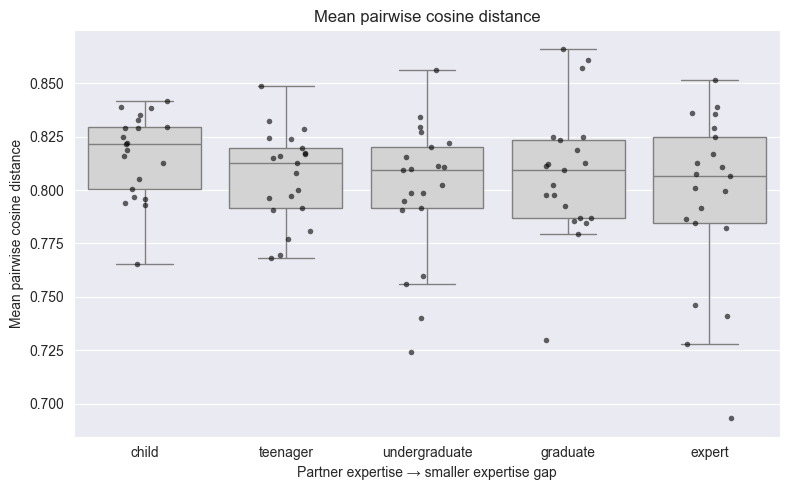

In [132]:
plot_metric_distribution(
    conversation_geometry,
    "pairwise_distance_mean",
    "Mean pairwise cosine distance",
)

In [130]:
conversation_geometry

,dataset,conversation_id,video_id,file_number,level,level_label,n_utterances,n_pairs,n_words,n_turns,...,nearest_neighbor_distance_median,knn_distance_median,maximum_available_rank,numerical_rank,total_variance,spectral_entropy,spectral_entropy_normalized,spectral_effective_rank,participation_ratio,pc1_variance_share
0,wired,wired_Talia_12,talia,12,0,child,27,351,315,14,...,0.501682,0.730119,26,26,0.825017,2.993523,0.918795,19.955860,16.181812,0.133915
1,wired,wired_astro_12,astro,12,0,child,56,1540,647,23,...,0.399942,0.595853,55,55,0.816119,3.508485,0.875516,33.397620,22.543430,0.121501
2,wired,wired_blockchain_12,blockchain,12,0,child,20,190,191,9,...,0.433820,0.788989,19,19,0.832669,2.693383,0.914736,14.781598,12.488393,0.148911
3,wired,wired_crispr_12,crispr,12,0,child,21,210,152,12,...,0.403874,0.757450,20,18,0.812852,2.639855,0.881205,14.011166,11.503852,0.174152
4,wired,wired_dimension_12,dimension,12,0,child,89,3916,689,50,...,0.310556,0.546307,88,80,0.795924,3.683957,0.822801,39.803570,22.846723,0.144173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,44,946,849,11,...,0.445602,0.629145,43,43,0.791545,3.391523,0.901713,29.711171,21.622795,0.128743
101,wired,wired_sensing_16,sensing,16,4,expert,56,1540,882,27,...,0.486627,0.652179,55,50,0.829185,3.464621,0.864570,31.964335,21.181876,0.141975
102,wired,wired_sleep_16,sleep,16,4,expert,31,465,823,13,...,0.341957,0.446537,30,30,0.693088,2.986731,0.878141,19.820781,13.797187,0.177302
103,wired,wired_time_16,time,16,4,expert,63,1953,1182,23,...,0.483401,0.622610,62,62,0.801034,3.757115,0.910345,42.824685,31.911495,0.083664


In [133]:
def plot_metric_trajectories(df, metric, ylabel=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    # One thin trajectory per topic
    sns.lineplot(
        data=df,
        x="level",
        y=metric,
        units="video_id",
        estimator=None,
        color="gray",
        alpha=0.3,
        linewidth=1,
        marker="o",
        markersize=3,
        ax=ax,
    )

    # Overall mean and 95% bootstrap CI
    sns.lineplot(
        data=df,
        x="level",
        y=metric,
        estimator="mean",
        errorbar=("ci", 95),
        color="black",
        linewidth=3,
        marker="o",
        markersize=7,
        ax=ax,
    )

    ax.set_xticks(range(5))
    ax.set_xticklabels(level_order)
    ax.set_xlabel("Partner expertise → smaller expertise gap")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(ylabel or metric)

    plt.tight_layout()
    plt.show()

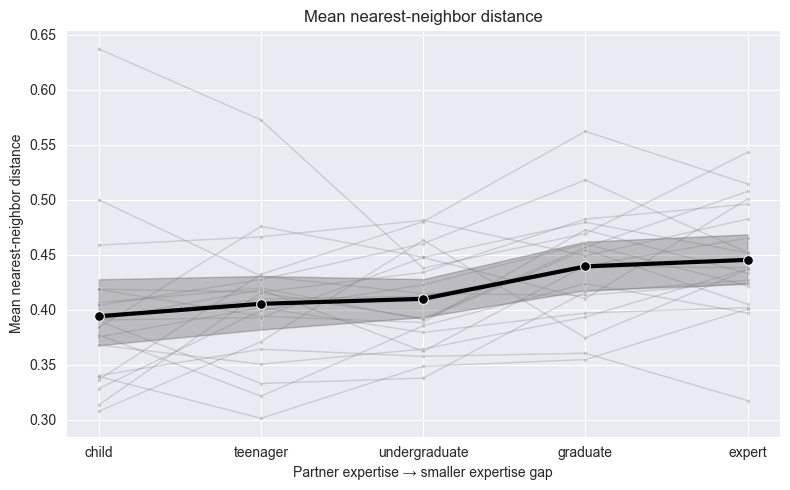

In [134]:
plot_metric_trajectories(
    conversation_geometry,
    "nearest_neighbor_distance_mean",
    "Mean nearest-neighbor distance",
)

In [135]:
def plot_child_expert_difference(df, metric, ylabel=None):
    endpoints = (
        df[df["level_label"].isin(["child", "expert"])]
        .pivot(
            index="video_id",
            columns="level_label",
            values=metric,
        )
        .dropna()
    )

    endpoints["difference"] = (
        endpoints["expert"] - endpoints["child"]
    )

    endpoints = endpoints.sort_values("difference")

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(
        endpoints["difference"],
        endpoints.index,
        color="black",
        s=35,
    )

    ax.axvline(0, color="gray", linestyle="--")

    ax.axvline(
        endpoints["difference"].mean(),
        color="red",
        linewidth=2,
        label=(
            "Mean difference = "
            f"{endpoints['difference'].mean():.3f}"
        ),
    )

    ax.set_xlabel(
        f"Expert − child difference\n"
        f"({ylabel or metric})"
    )
    ax.set_ylabel("Topic")
    ax.set_title("Smallest gap versus largest gap")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [136]:
def plot_sample_size_diagnostic(df, metric, ylabel=None):
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x="n_utterances",
        y=metric,
        hue="level_label",
        hue_order=level_order,
        alpha=0.8,
    )

    sns.regplot(
        data=df,
        x="n_utterances",
        y=metric,
        scatter=False,
        color="black",
        line_kws={"linestyle": "--"},
    )

    plt.xlabel("Number of utterances")
    plt.ylabel(ylabel or metric)
    plt.title(f"{ylabel or metric} versus conversation size")
    plt.tight_layout()
    plt.show()

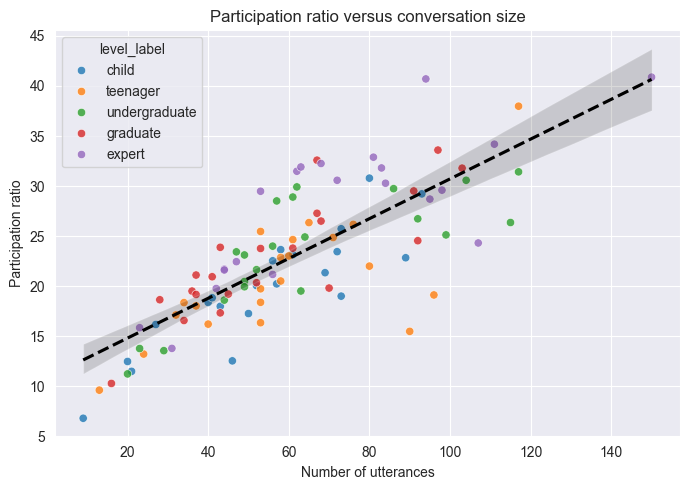

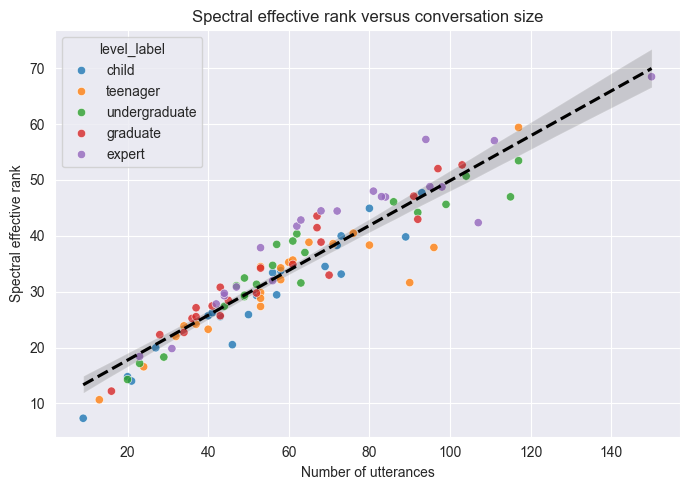

In [137]:
plot_sample_size_diagnostic(
    conversation_geometry,
    "participation_ratio",
    "Participation ratio",
)

plot_sample_size_diagnostic(
    conversation_geometry,
    "spectral_effective_rank",
    "Spectral effective rank",
)

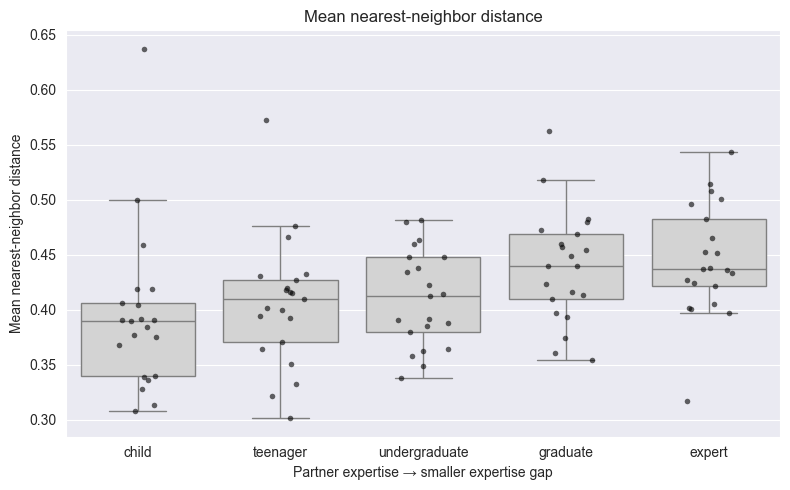

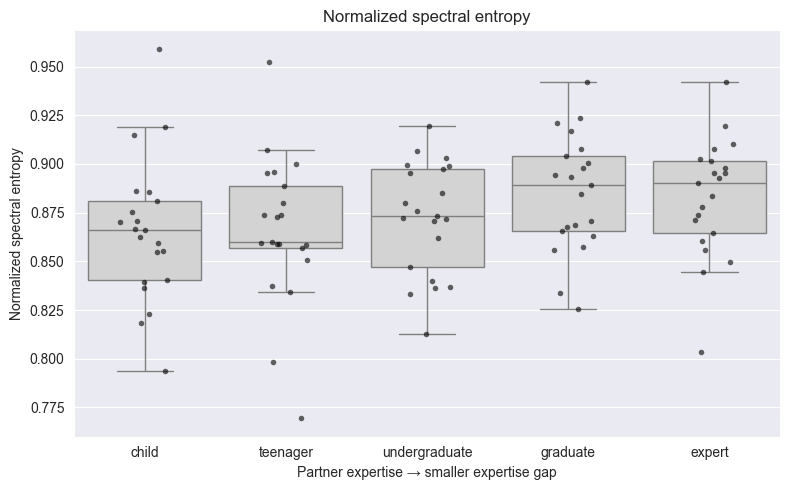

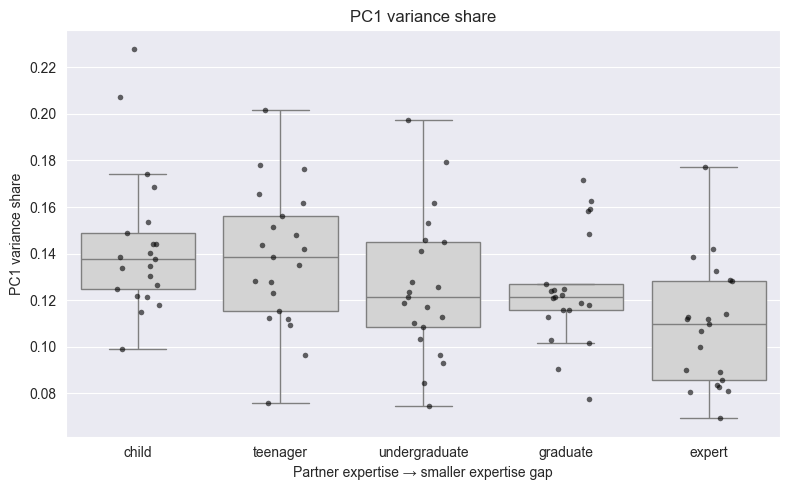

In [138]:
plot_metric_distribution(
    conversation_geometry,
    "nearest_neighbor_distance_mean",
    "Mean nearest-neighbor distance",
)

plot_metric_distribution(
    conversation_geometry,
    "spectral_entropy_normalized",
    "Normalized spectral entropy",
)

plot_metric_distribution(
    conversation_geometry,
    "pc1_variance_share",
    "PC1 variance share",
)

# multilevel modeling for each metric

model each metric using a mixed effect(multilevel) model. (https://pmc.ncbi.nlm.nih.gov/articles/PMC10171296/)


gap scores: 12->4 13->3 14->2 15->1 16->0

In [139]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

analysis_df = conversation_geometry.copy()

gap_map = {
    "expert": 0,
    "graduate": 1,
    "undergraduate": 2,
    "teenager": 3,
    "child": 4,
}

analysis_df["gap_score"] = (
    analysis_df["level_label"]
    .map(gap_map)
    .astype(float)
)

# Centering makes the intercept represent the middle expertise condition.
analysis_df["gap_c"] = (
    analysis_df["gap_score"]
    - analysis_df["gap_score"].mean()
)

# Use a composite identifier in case video_id is repeated across datasets.
analysis_df["video_group"] = (
    analysis_df["dataset"].astype(str)
    + "::"
    + analysis_df["video_id"].astype(str)
)

# Length variable for sensitivity analyses
analysis_df["log_n_utterances"] = np.log(
    analysis_df["n_utterances"]
)

analysis_df["log_n_utterances_c"] = (
    analysis_df["log_n_utterances"]
    - analysis_df["log_n_utterances"].mean()
)

analysis_df["level_label"] = pd.Categorical(
    analysis_df["level_label"],
    categories=[
        "expert",
        "graduate",
        "undergraduate",
        "teenager",
        "child",
    ],
    ordered=True,
)

In [140]:
#standardize outcomes
def prepare_metric(df, metric):
    model_df = df[
        [
            metric,
            "gap_score",
            "gap_c",
            "level_label",
            "video_group",
            "n_utterances",
            "log_n_utterances_c",
        ]
    ].dropna().copy()

    model_df["outcome_z"] = (
        model_df[metric] - model_df[metric].mean()
    ) / model_df[metric].std(ddof=1)

    return model_df

-> betagap represents SD change in the metric per gap level

## model 0 (null model)

separates vaience into 1: between video variance 2: within video residual variance

In [141]:
metric = "pairwise_distance_mean"
model_df = prepare_metric(analysis_df, metric)

model_0 = smf.mixedlm(
    "outcome_z ~ 1",
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=True,
    method="lbfgs",
)

print(model_0.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: outcome_z
No. Observations: 105     Method:             REML     
No. Groups:       21      Scale:              1.0000   
Min. group size:  5       Log-Likelihood:     -149.8966
Max. group size:  5       Converged:          Yes      
Mean group size:  5.0                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.000    0.098 -0.000 1.000 -0.191  0.191
Group Var     0.000    0.047                           



/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [142]:
#intraclass correlation
between_video_variance = model_0.cov_re.iloc[0, 0]
residual_variance = model_0.scale

icc = (
    between_video_variance
    / (between_video_variance + residual_variance)
)

print("ICC:", icc)

ICC: 5.268700378643449e-33
